--- STEP PROGRESSION ---
 Step     m1     m2      b    MSE
    0 0.0000 0.0000 0.0000 3.4800
  100 0.2486 0.1854 0.2890 0.0536
  200 0.2148 0.1897 0.4439 0.0281
  300 0.1948 0.1869 0.5499 0.0164
  400 0.1840 0.1798 0.6229 0.0108
  500 0.1790 0.1703 0.6735 0.0081
  600 0.1778 0.1597 0.7090 0.0067
  700 0.1789 0.1485 0.7342 0.0060
  800 0.1815 0.1375 0.7523 0.0055
  900 0.1848 0.1267 0.7656 0.0052
 1000 0.1884 0.1165 0.7756 0.0050


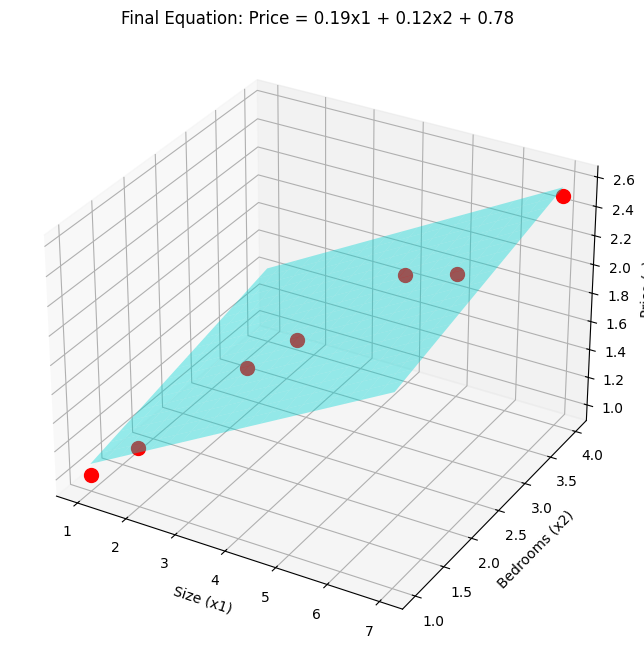

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Data Setup
x1 = np.array([1, 2, 3, 4, 5, 6, 7]) # Size
x2 = np.array([1, 1, 2, 2, 3, 3, 4]) # Bedrooms
y = np.array([1.0, 1.3, 1.6, 1.9, 2.1, 2.2, 2.5]) # Price

# 2. Parameters
m1, m2, b = 0.0, 0.0, 0.0
L = 0.01       # Learning Rate
epochs = 1001
n = float(len(y))

history = []

# 3. Gradient Descent Loop
for i in range(epochs):
    y_hat = m1*x1 + m2*x2 + b
    mse = np.mean((y - y_hat)**2)

    if i % 100 == 0:
        history.append([i, m1, m2, b, mse])

    # Derivatives
    dm1 = (2/n) * np.sum(x1 * (y_hat - y))
    dm2 = (2/n) * np.sum(x2 * (y_hat - y))
    db = (2/n) * np.sum(y_hat - y)

    # Update Weights
    m1 -= L * dm1
    m2 -= L * dm2
    b -= L * db

# 4. Print Progression Tables
df_steps = pd.DataFrame(history, columns=['Step', 'm1', 'm2', 'b', 'MSE'])
print("--- STEP PROGRESSION ---")
print(df_steps.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# 5. Create 3D Visualization
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the Actual Data Points (Red Dots)
ax.scatter(x1, x2, y, color='red', s=100, label='Actual Data', depthshade=False)

# Create the Regression Plane
x1_surf = np.linspace(min(x1), max(x1), 20)
x2_surf = np.linspace(min(x2), max(x2), 20)
X1_SURF, X2_SURF = np.meshgrid(x1_surf, x2_surf)
Y_SURF = m1 * X1_SURF + m2 * X2_SURF + b

# Plot the Surface (The "Best Fit" Plane)
ax.plot_surface(X1_SURF, X2_SURF, Y_SURF, color='cyan', alpha=0.4, label='Regression Plane')

# Labels and Styling
ax.set_xlabel('Size (x1)')
ax.set_ylabel('Bedrooms (x2)')
ax.set_zlabel('Price (y)')
ax.set_title(f'Final Equation: Price = {m1:.2f}x1 + {m2:.2f}x2 + {b:.2f}')

plt.show()